In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

In [2]:
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"

In [3]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["target_original"] = data.target

df["target"] = 1 - df["target_original"]

df["target_name"] = df["target"].map({
    0: "benign",
    1: "malignant"
})

print("데이터 크기 (행, 열):", df.shape)

데이터 크기 (행, 열): (569, 33)


In [4]:
df[["target_original", "target", "target_name"]].head()

,target_original,target,target_name
0,0,1,malignant
1,0,1,malignant
2,0,1,malignant
3,0,1,malignant
4,0,1,malignant


In [5]:
df["target_name"].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [6]:
X = df.drop(columns=["target_original", "target", "target_name"])

y = df["target"]

print("X의 열 개수:", X.shape[1])
print("정답 관련 컬럼이 X에 있나요?",
        any(col in X.columns for col in ["target_original", "target", "target_name"]))

X의 열 개수: 30
정답 관련 컬럼이 X에 있나요? False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify= y
)

print("학습용 데이터 개수:", X_train.shape[0])
print("평가용 데이터 개수:", X_test.shape[0])

학습용 데이터 개수: 455
평가용 데이터 개수: 114


In [8]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

print("예측 완료! 예측한 데이터 개수:", len(y_pred))
print("예측값 예시 (앞 10개):", y_pred[:10])
print("malignant 확률 예시 (앞 5개):", y_pred_proba[:5].round(3))

예측 완료! 예측한 데이터 개수: 114
예측값 예시 (앞 10개): [0 1 0 1 0 0 1 0 0 0]
malignant 확률 예시 (앞 5개): [0.001 1.    0.04  0.993 0.017]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("accuracy:", accuracy)
print(f"즉, 전체의 약 {accuracy*100:.1f}% 를 맞혔습니다.")

accuracy: 0.9736842105263158
즉, 전체의 약 97.4% 를 맞혔습니다.


In [10]:
class_names = ["benign", "malignant"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print(cm)

[[72  0]
 [ 3 39]]


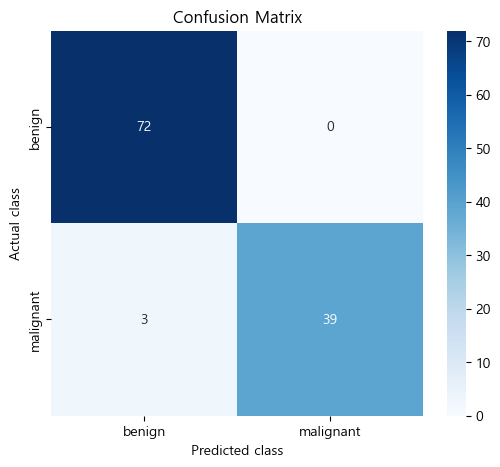

In [11]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix")
plt.show()

In [12]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [13]:
X_test_reset = X_test.reset_index(drop=True).copy()
y_test_reset = y_test.reset_index(drop=True)

result_df = X_test_reset.copy()

result_df["y_true"] = y_test_reset
result_df["y_pred"] = y_pred

result_df["malignant_probability"] = y_pred_proba

result_df["y_true_name"] = result_df["y_true"].map({0: "benign", 1: "malignant"})
result_df["y_pred_name"] = result_df["y_pred"].map({0: "benign", 1: "malignant"})

result_df["is_correct"] = result_df["y_true"] == result_df["y_pred"]

result_df[["y_true", "y_pred", "y_true_name", "y_pred_name", "malignant_probability", "is_correct"]].head()

,y_true,y_pred,y_true_name,y_pred_name,malignant_probability,is_correct
0,0,0,benign,benign,0.001136,True
1,1,1,malignant,malignant,0.999783,True
2,0,0,benign,benign,0.039927,True
3,1,1,malignant,malignant,0.993436,True
4,0,0,benign,benign,0.016957,True


In [14]:
wrong_df = result_df[result_df["is_correct"] == False]

print("틀린 예측 개수:", len(wrong_df))

if len(wrong_df) == 0:
    print("이번 test split에서는 틀린 예측이 발생하지 않았습니다.")
else:
    important_columns = [
        "y_true_name",
        "y_pred_name",
        "malignant_probability",
        "mean radius",
        "mean perimeter",
        "mean area",
        "worst radius",
        "worst perimeter",
        "worst area",
        "worst concave points"
    ]

    available_columns = [col for col in important_columns if col in wrong_df.columns]

    display(wrong_df[available_columns].round(3))

틀린 예측 개수: 3


,y_true_name,y_pred_name,malignant_probability,mean radius,mean perimeter,mean area,worst radius,worst perimeter,worst area,worst concave points
16,malignant,benign,0.003,13.80,90.43,584.1,16.57,110.3,812.4,0.138
69,malignant,benign,0.377,12.45,82.57,477.1,15.47,103.4,741.6,0.174
112,malignant,benign,0.261,15.12,98.78,716.6,17.77,117.7,989.5,0.125


In [15]:
false_negative_df = result_df[
    (result_df["y_true"] == 1) &
    (result_df["y_pred"] == 0)
]

print("False Negative 개수:", len(false_negative_df))

if len(false_negative_df) == 0:
    print("이번 test split에서는 false negative가 발생하지 않았습니다.")
else:
    display(false_negative_df[["y_true_name", "y_pred_name"]])

False Negative 개수: 3


,y_true_name,y_pred_name
16,malignant,benign
69,malignant,benign
112,malignant,benign


In [16]:
false_positive_df = result_df[
    (result_df["y_true"] == 0) &
    (result_df["y_pred"] == 1)
]

print("False Positive 개수:", len(false_positive_df))

if len(false_positive_df) == 0:
    print("이번 test split에서는 false positive가 발생하지 않았습니다.")
else:
    display(false_positive_df[["y_true_name", "y_pred_name"]])

False Positive 개수: 0
이번 test split에서는 false positive가 발생하지 않았습니다.


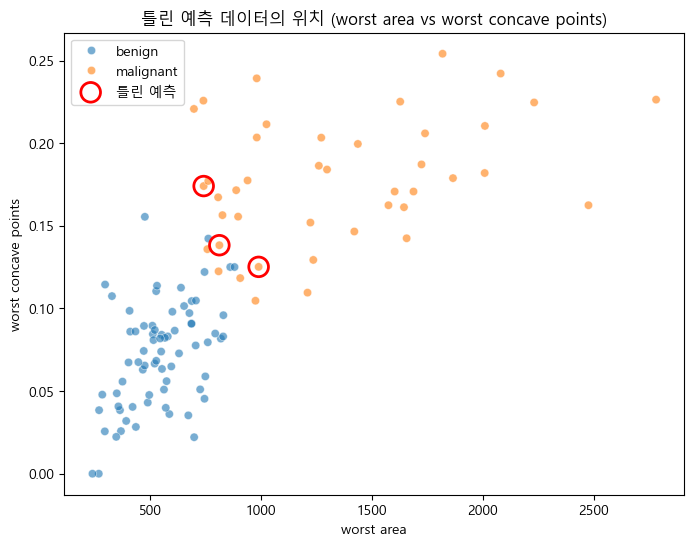

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=result_df,
    x="worst area",
    y="worst concave points",
    hue="y_true_name",
    alpha=0.6
)

if len(wrong_df) > 0:
    plt.scatter(
        wrong_df["worst area"],
        wrong_df["worst concave points"],
        s=200,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="틀린 예측"
    )
else:
    print("이번 test split에서는 틀린 예측이 없어 별도로 표시할 점이 없습니다.")

plt.title("틀린 예측 데이터의 위치 (worst area vs worst concave points)")
plt.xlabel("worst area")
plt.ylabel("worst concave points")
plt.legend()
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA 변환 후 학습용 데이터 shape:", X_train_pca.shape)
print("PCA 변환 후 평가용 데이터 shape:", X_test_pca.shape)

print("PC1 설명 분산 비율:", round(pca.explained_variance_ratio_[0], 3))
print("PC2 설명 분산 비율:", round(pca.explained_variance_ratio_[1], 3))
print("PC1 + PC2 설명 분산 비율:", round(pca.explained_variance_ratio_.sum(), 3))


PCA 변환 후 학습용 데이터 shape: (455, 2)
PCA 변환 후 평가용 데이터 shape: (114, 2)
PC1 설명 분산 비율: 0.446
PC2 설명 분산 비율: 0.185
PC1 + PC2 설명 분산 비율: 0.631


In [19]:
pca_df = pd.DataFrame({
    "PC1": X_test_pca[:, 0],
    "PC2": X_test_pca[:, 1],
    "y_true": y_test.values,
    "y_pred": y_pred,
    "malignant_probability": y_pred_proba
})

pca_df["y_true_name"] = pca_df["y_true"].map({
    0: "benign",
    1: "malignant"
})

pca_df["is_correct"] = pca_df["y_true"] == pca_df["y_pred"]

pca_df.head()

,PC1,PC2,y_true,y_pred,malignant_probability,y_true_name,is_correct
0,-2.954871,0.471308,0,0,0.001136,benign,True
1,6.892485,-2.047321,1,1,0.999783,malignant,True
2,-0.125826,-0.058798,0,0,0.039927,benign,True
3,0.586226,0.666002,1,1,0.993436,malignant,True
4,-1.868729,-1.530491,0,0,0.016957,benign,True


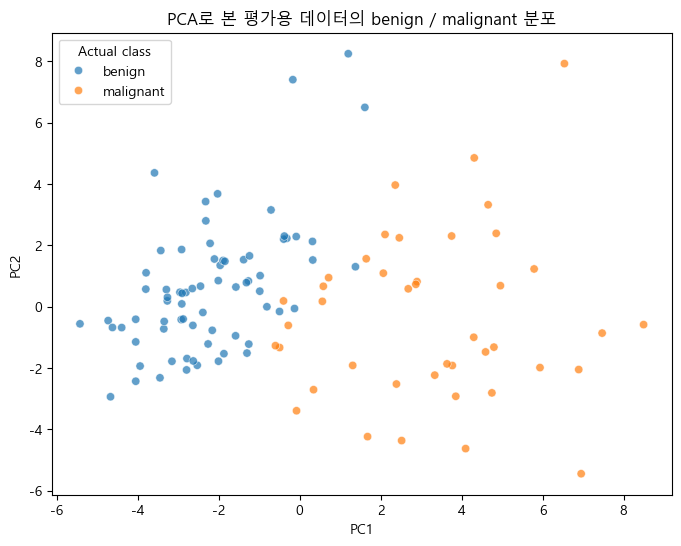

In [20]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="y_true_name",
    alpha=0.7
)

plt.title("PCA로 본 평가용 데이터의 benign / malignant 분포")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Actual class")
plt.show()

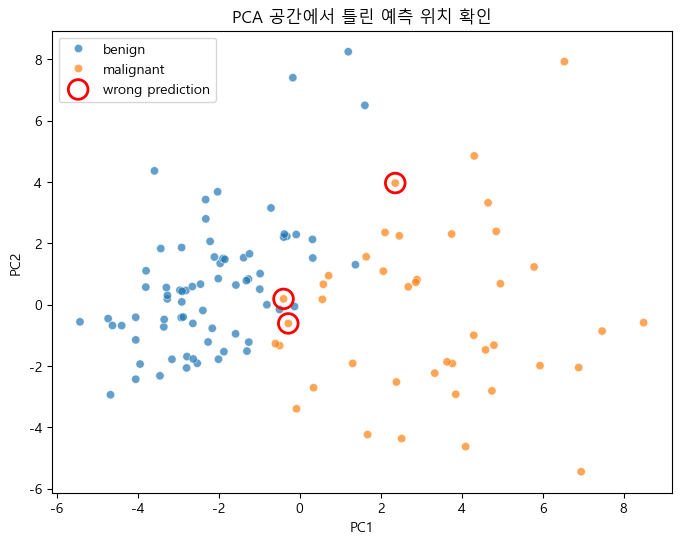

In [21]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="y_true_name",
    alpha=0.7
)

wrong_pca_df = pca_df[pca_df["is_correct"] == False]

if len(wrong_pca_df) > 0:
    plt.scatter(
        wrong_pca_df["PC1"],
        wrong_pca_df["PC2"],
        s=200,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="wrong prediction"
    )

plt.title("PCA 공간에서 틀린 예측 위치 확인")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

threshold_list = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]

for threshold in threshold_list:
    print("=" * 70)
    print(f"threshold = {threshold}")
    print("=" * 70)

    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    cm_threshold = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm_threshold,
        index=["Actual benign", "Actual malignant"],
        columns=["Predicted benign", "Predicted malignant"]
    )

    print("\n[Confusion Matrix]")
    display(cm_df)

    fp = cm_threshold[0, 1]
    fn = cm_threshold[1, 0]

    print(
        f"[핵심 해석] threshold={threshold} -> "
        f"FN={fn}개(악성을 양성으로 놓침), "
        f"FP={fp}개(양성을 악성으로 잘못 의심)"
    )

    print("\n[Classification Report]")
    print(
        classification_report(
            y_test,
            y_pred_threshold,
            labels=[0, 1],
            target_names=["benign", "malignant"],
            zero_division=0
        )
    )

    print()

threshold = 0.5

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39


[핵심 해석] threshold=0.5 -> FN=3개(악성을 양성으로 놓침), FP=0개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.4

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39


[핵심 해석] threshold=0.4 -> FN=3개(악성을 양성으로 놓침), FP=0개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.3

[Confusion Matrix]


...

[핵심 해석] threshold=0.05 -> FN=1개(악성을 양성으로 놓침), FP=2개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.99      0.97      0.98        72
   malignant       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.01

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,61,11
Actual malignant,1,41


[핵심 해석] threshold=0.01 -> FN=1개(악성을 양성으로 놓침), FP=11개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.98      0.85      0.91        72
   malignant       0.79      0.98      0.87        42

    accuracy                           0.89       114
   macro avg       0.89      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114


threshold = 0.001

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,42,30
Actual malignant,0,42


[핵심 해석] threshold=0.001 -> FN=0개(악성을 양성으로 놓침), FP=30개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       1.00      0.58      0.74        72
   malignant       0.58      1.00      0.74        42

    accuracy                           0.74       114
   macro avg       0.79      0.79      0.74       114
weighted avg       0.85      0.74      0.74       114




scaler_exam_df = pd.DataFrame({
    "house_price": [120000, 115000, 10000, 110000, 119000],
    "owner_age":[24, 38, 65, 42, 52],
    "is_sale_next_month":[0, 0, 1, 1, 1]
})

scaler_exam_df[["house_price", "owner_age"]].mean()

scaler_exam_df[["house_price", "owner_age"]].std()

(scaler_exam_df[["house_price", "owner_age"]] - scaler_exam_df[["house_price", "owner_age"]].mean())\
    /scaler_exam_df[["house_price", "owner_age"]].std()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler_exam_df[["house_price", "owner_age"]]

scaler.fit(scaler_exam_df[["house_price", "owner_age"]])

scaler.transform(scaler_exam_df[["house_price", "owner_age"]])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

X_test_scaled = scaler.transform(X_test)
X_test_scaled

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit_transform(X_train_scaled)

In [25]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

In [26]:
fpr

array([0.  , 0.  , 0.  , 0.25, 0.25, 1.  ])

In [27]:
tpr

array([0.        , 0.02380952, 0.97619048, 0.97619048, 1.        ,
       1.        ])

In [28]:
threshold

array([           inf, 9.99835610e-01, 2.60724038e-01, 2.99005839e-03,
       2.65839673e-03, 4.52879540e-05])

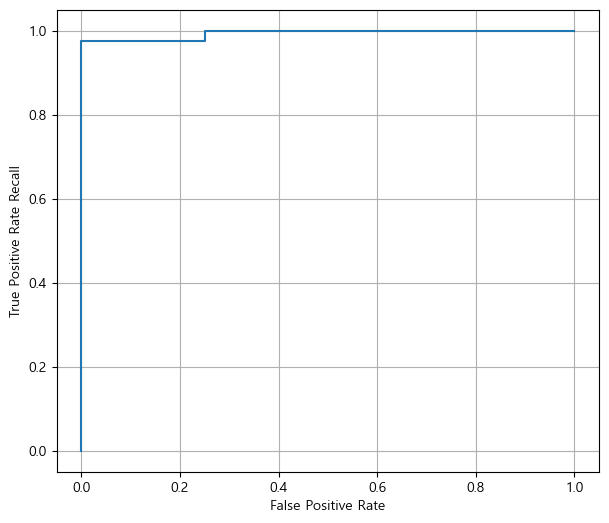

In [29]:
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate Recall")
plt.grid(True)